In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import trueskill
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [120]:
def load_and_preprocess_data(csv_path):
    """Load and preprocess chess data"""
    try:
        df = pd.read_csv(csv_path)
        print(f" Loaded {len(df)} games from dataset")
        print(f" Columns: {list(df.columns)}")
        
        # Identify columns automatically
        player_cols = {}
        outcome_col = None
        
        for col in df.columns:
            col_lower = col.lower()
            if any(x in col_lower for x in ['white_username', 'white_user', 'white_player', 'white', 'player1']):
                player_cols['white'] = col
            elif any(x in col_lower for x in ['black_username', 'black_user', 'black_player', 'black', 'player2']):
                player_cols['black'] = col
            elif any(x in col_lower for x in ['winner', 'result', 'outcome']):
                outcome_col = col
        
        print(f" Identified columns: {player_cols}, outcome: {outcome_col}")
        
        # Create clean dataset
        trueskill_data = []
        for idx, row in df.iterrows():
            white_player = str(row[player_cols['white']])
            black_player = str(row[player_cols['black']])
            outcome = row[outcome_col]
            
            if outcome in ['white', 'White', '1-0', 1]:
                result = 1  # white wins
            elif outcome in ['black', 'Black', '0-1', 0]:
                result = 0  # black wins
            elif outcome in ['draw', 'Draw', '1/2-1/2', 0.5]:
                result = 0.5  # draw
            else:
                continue
            
            trueskill_data.append({
                'game_id': idx,
                'player1': white_player,
                'player2': black_player,
                'result': result,
                'timestamp': idx
            })
        
        trueskill_df = pd.DataFrame(trueskill_data)
        print(f" Created clean dataset: {len(trueskill_df)} games")
        print(f" Unique players: {len(set(trueskill_df['player1'].tolist() + trueskill_df['player2'].tolist()))}")
        print(f" Outcome distribution:\n{trueskill_df['result'].value_counts()}")
        
        return trueskill_df
        
    except Exception as e:
        print(f"✗ Error loading data: {e}")
        return None

In [121]:
csv_path = '/Users/larasabha/desktop/chess_trueskill_data.csv'
trueskill_df = load_and_preprocess_data(csv_path)

if trueskill_df is None:
    print("Please fix the data loading issue before continuing")
    exit()

print("\n" + "=" * 60)
print("calculating trueskill ratings")
print("=" * 60)

def calculate_trueskill_ratings(trueskill_df):
    """Calculate TrueSkill ratings for all players"""
    env = trueskill.TrueSkill(draw_probability=0.1)  # 10% draw probability for chess
    ratings = {}
    rating_history = defaultdict(list)
    
    print(f"Processing {len(trueskill_df)} games...")
    
    for idx, row in trueskill_df.iterrows():
        p1, p2 = row['player1'], row['player2']
        result = row['result']
        
        r1 = ratings.get(p1, env.create_rating())
        r2 = ratings.get(p2, env.create_rating())
        
        rating_history[p1].append({
            'game': idx,
            'mu': r1.mu,
            'sigma': r1.sigma,
            'rating': r1.mu - 3 * r1.sigma
        })
        rating_history[p2].append({
            'game': idx,
            'mu': r2.mu,
            'sigma': r2.sigma,
            'rating': r2.mu - 3 * r2.sigma
        })
        
        if result == 1:  # player 1 wins
            new_r1, new_r2 = env.rate([[r1], [r2]], ranks=[0, 1])
        elif result == 0:  # player 2 wins
            new_r1, new_r2 = env.rate([[r1], [r2]], ranks=[1, 0])
        else:  # draw
            new_r1, new_r2 = env.rate([[r1], [r2]], ranks=[0, 0])
        
        ratings[p1], ratings[p2] = new_r1[0], new_r2[0]
    
    print(f"ratings for {len(ratings)} players")
    return ratings, rating_history

ratings, rating_history = calculate_trueskill_ratings(trueskill_df)


 Loaded 20058 games from dataset
 Columns: ['game_id', 'player1', 'player2', 'winner', 'result', 'timestamp']
 Identified columns: {'white': 'player1', 'black': 'player2'}, outcome: result
 Created clean dataset: 20058 games
 Unique players: 1622
 Outcome distribution:
result
1.0    10001
0.0     9107
0.5      950
Name: count, dtype: int64

calculating trueskill ratings
Processing 20058 games...
ratings for 1622 players


In [122]:
print("\n" + "=" * 60)
print("generating player stats")
print("=" * 60)

def calculate_player_statistics(trueskill_df):
    stats = {}
    
    for _, row in trueskill_df.iterrows():
        p1, p2 = row['player1'], row['player2']
        result = row['result']
        
        for player in [p1, p2]:
            if player not in stats:
                stats[player] = {
                    'games': 0, 'wins': 0, 'losses': 0, 'draws': 0,
                    'points': 0
                }
        
        stats[p1]['games'] += 1
        stats[p2]['games'] += 1
        
        if result == 1:  # player 1 wins
            stats[p1]['wins'] += 1
            stats[p1]['points'] += 1
            stats[p2]['losses'] += 1
        elif result == 0:  # player 2 wins
            stats[p2]['wins'] += 1
            stats[p2]['points'] += 1
            stats[p1]['losses'] += 1
        else:  # Draw
            stats[p1]['draws'] += 1
            stats[p1]['points'] += 0.5
            stats[p2]['draws'] += 1
            stats[p2]['points'] += 0.5
    
    stats_df = pd.DataFrame.from_dict(stats, orient='index')
    stats_df['win_rate'] = stats_df['wins'] / stats_df['games']
    stats_df['score_rate'] = stats_df['points'] / stats_df['games']
    stats_df.index.name = 'player'
    stats_df.reset_index(inplace=True)
    
    return stats_df

player_stats = calculate_player_statistics(trueskill_df)

# rankings
player_ratings = []
for player, rating in ratings.items():
    player_ratings.append({
        'player': player,
        'mu': rating.mu,
        'sigma': rating.sigma,
        'trueskill_rating': rating.mu - 3 * rating.sigma,
        'conservative_rating': rating.mu - 2 * rating.sigma,
        'optimistic_rating': rating.mu + 2 * rating.sigma
    })

trueskill_rankings = pd.DataFrame(player_ratings)

final_rankings = trueskill_rankings.merge(player_stats, on='player', how='left')

experienced_players = final_rankings[final_rankings['games'] >= 5].copy()

print(f"total players: {len(final_rankings)}")
print(f"experienced players (≥5 games): {len(experienced_players)}")


generating player stats
total players: 1622
experienced players (≥5 games): 1304


In [123]:
print("\n" + "=" * 60)
print("prediction accuracy analysis")
print("=" * 60)

def evaluate_prediction_accuracy(trueskill_df, ratings):
    #  80% train, 20% test
    split_point = int(len(trueskill_df) * 0.8)
    train_data = trueskill_df[:split_point].copy()
    test_data = trueskill_df[split_point:].copy()
    
    print(f"Training games: {len(train_data)}")
    print(f"Testing games: {len(test_data)}")
    
    train_stats = calculate_player_statistics(train_data)
    win_rates = dict(zip(train_stats['player'], train_stats['score_rate']))
    
    trueskill_correct = 0
    winrate_correct = 0
    total_predictions = 0
    
    predictions_data = []
    
    for _, row in test_data.iterrows():
        p1, p2 = row['player1'], row['player2']
        actual_result = row['result']
        
        if p1 not in ratings or p2 not in ratings:
            continue
        
        r1 = ratings[p1]
        r2 = ratings[p2]
        win_prob = trueskill.quality_1vs1(r1, r2)
        
        if r1.mu > r2.mu:
            trueskill_pred = 1  # player 1 favored
        elif r2.mu > r1.mu:
            trueskill_pred = 0  # player 2 favored
        else:
            trueskill_pred = 0.5  # equal ratings
        
        p1_winrate = win_rates.get(p1, 0.5)
        p2_winrate = win_rates.get(p2, 0.5)
        
        if p1_winrate > p2_winrate:
            winrate_pred = 1
        elif p2_winrate > p1_winrate:
            winrate_pred = 0
        else:
            winrate_pred = 0.5
        
        if trueskill_pred == actual_result or (trueskill_pred == 0.5 and actual_result == 0.5):
            trueskill_correct += 1
        elif trueskill_pred == 1 and actual_result == 1:
            trueskill_correct += 1
        elif trueskill_pred == 0 and actual_result == 0:
            trueskill_correct += 1
        
        if winrate_pred == actual_result or (winrate_pred == 0.5 and actual_result == 0.5):
            winrate_correct += 1
        elif winrate_pred == 1 and actual_result == 1:
            winrate_correct += 1
        elif winrate_pred == 0 and actual_result == 0:
            winrate_correct += 1
        
        predictions_data.append({
            'player1': p1,
            'player2': p2,
            'actual': actual_result,
            'trueskill_pred': trueskill_pred,
            'winrate_pred': winrate_pred,
            'p1_rating': r1.mu - 3 * r1.sigma,
            'p2_rating': r2.mu - 3 * r2.sigma,
            'p1_winrate': p1_winrate,
            'p2_winrate': p2_winrate
        })
        
        total_predictions += 1
    
    trueskill_accuracy = trueskill_correct / total_predictions
    winrate_accuracy = winrate_correct / total_predictions
    
    print(f"TrueSkill Accuracy: {trueskill_accuracy:.3f} ({trueskill_correct}/{total_predictions})")
    print(f"Win Rate Accuracy: {winrate_accuracy:.3f} ({winrate_correct}/{total_predictions})")
    print(f"Improvement: {(trueskill_accuracy - winrate_accuracy) * 100:.1f} percentage points")
    
    return {
        'trueskill_accuracy': trueskill_accuracy,
        'winrate_accuracy': winrate_accuracy,
        'total_predictions': total_predictions,
        'predictions_data': pd.DataFrame(predictions_data)
    }

prediction_results = evaluate_prediction_accuracy(trueskill_df, ratings)


prediction accuracy analysis
Training games: 16046
Testing games: 4012
TrueSkill Accuracy: 0.644 (2583/4012)
Win Rate Accuracy: 0.529 (2122/4012)
Improvement: 11.5 percentage points


In [136]:
print("\n" + "=" * 60)
print("statistical correlation analysis")
print("=" * 60)

def perform_statistical_analysis(experienced_players):
    print("correlation analysis:")
    
    # TrueSkill vs Score Rate
    corr_trueskill_score, p_val_1 = pearsonr(experienced_players['trueskill_rating'], experienced_players['score_rate'])
    print(f"TrueSkill vs Score Rate: r = {corr_trueskill_score:.3f}, p = {p_val_1:.3f}")
    
    # TrueSkill vs Games Played
    corr_games, p_val_2 = pearsonr(experienced_players['trueskill_rating'], experienced_players['games'])
    print(f"TrueSkill vs Games Played: r = {corr_games:.3f}, p = {p_val_2:.3f}")
    
    # Sigma vs Games Played (uncertainty should decrease)
    corr_sigma_games, p_val_3 = pearsonr(experienced_players['sigma'], experienced_players['games'])
    print(f" Uncertainty vs Games Played: r = {corr_sigma_games:.3f}, p = {p_val_3:.3f}")
    
    print(f"\nRating Distribution Analysis:")
    print(f"  Mean TrueSkill Rating: {experienced_players['trueskill_rating'].mean():.2f}")
    print(f"  Std TrueSkill Rating: {experienced_players['trueskill_rating'].std():.2f}")
    print(f"  Mean Uncertainty (σ): {experienced_players['sigma'].mean():.2f}")
    print(f"  Std Uncertainty (σ): {experienced_players['sigma'].std():.2f}")
    
    return {
        'correlations': {
            'trueskill_score': (corr_trueskill_score, p_val_1),
            'trueskill_games': (corr_games, p_val_2),
            'sigma_games': (corr_sigma_games, p_val_3)
        }
    }

stats_results = perform_statistical_analysis(experienced_players)


statistical correlation analysis
correlation analysis:
TrueSkill vs Score Rate: r = 0.804, p = 0.000
TrueSkill vs Games Played: r = 0.165, p = 0.000
 Uncertainty vs Games Played: r = -0.353, p = 0.000

Rating Distribution Analysis:
  Mean TrueSkill Rating: 19.51
  Std TrueSkill Rating: 5.04
  Mean Uncertainty (σ): 1.96
  Std Uncertainty (σ): 0.86



generating graphs


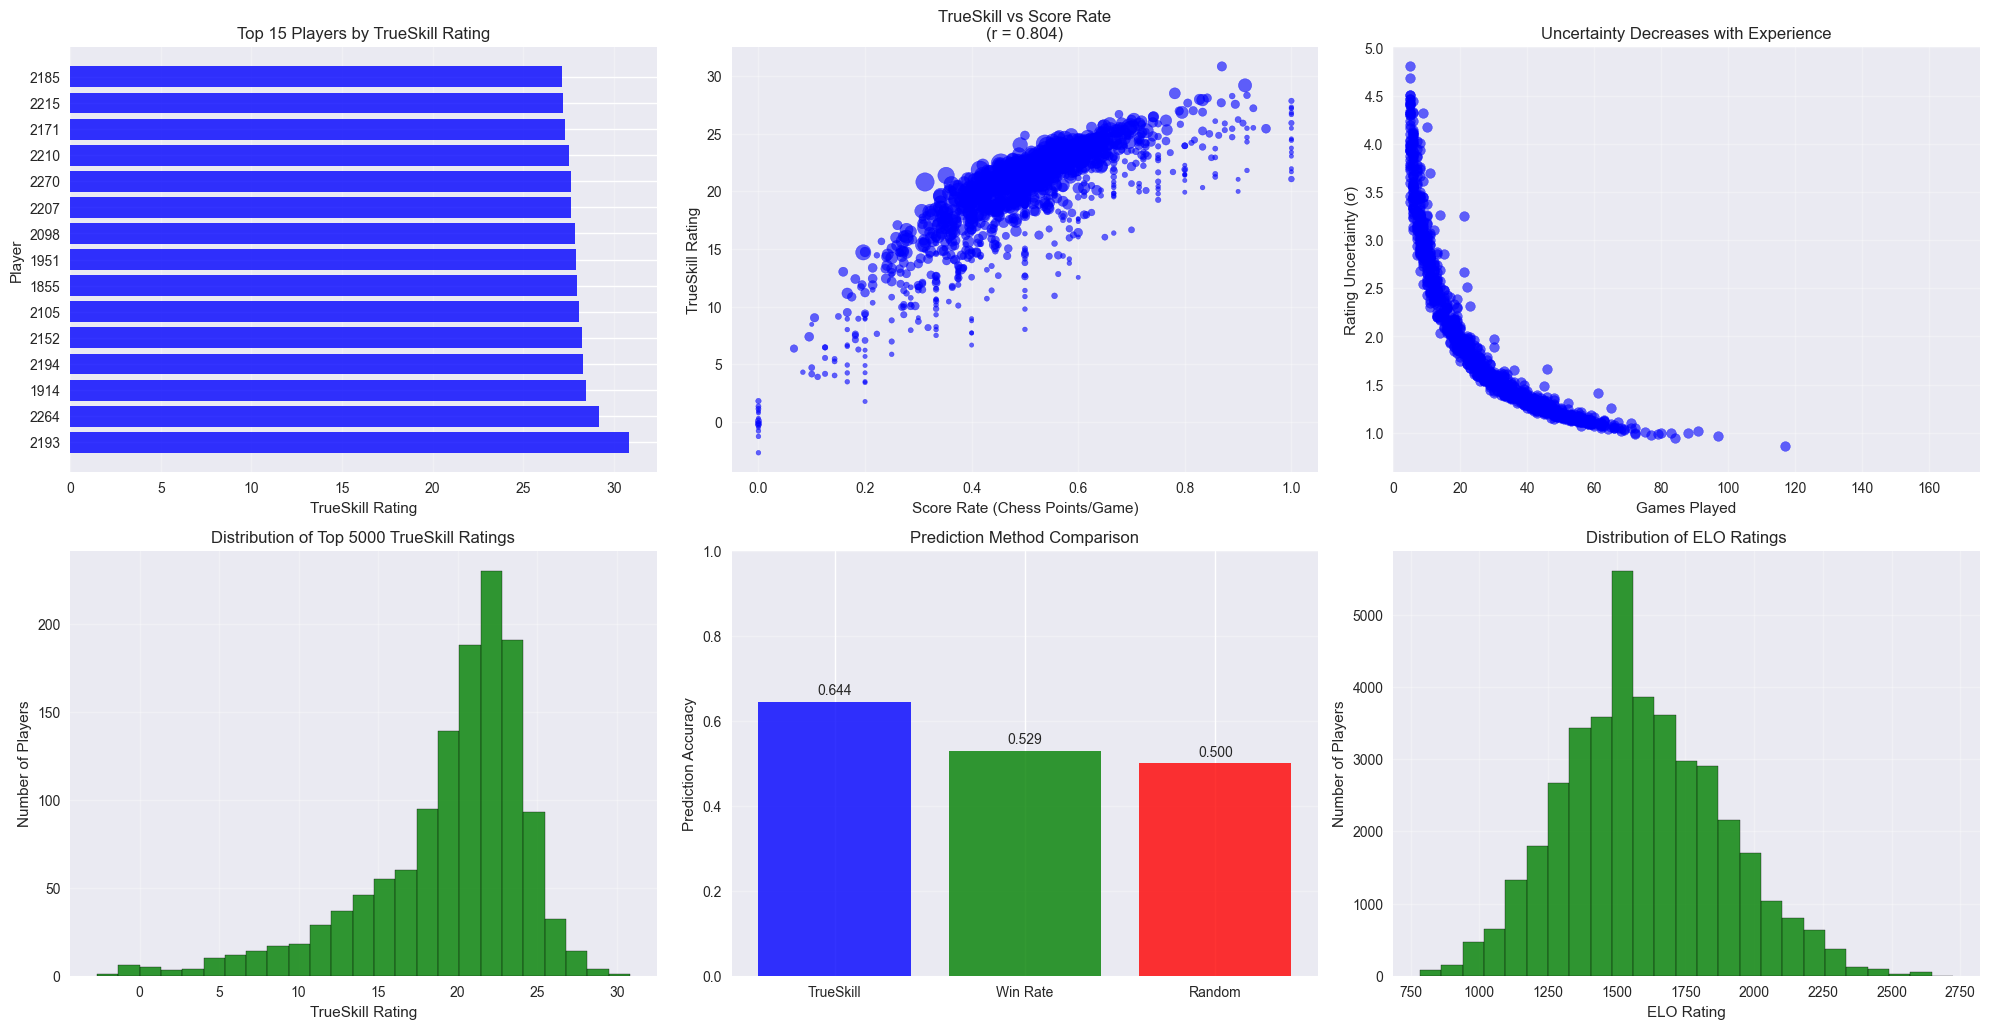

In [125]:
print("\n" + "=" * 60)
print("generating graphs")
print("=" * 60)

fig = plt.figure(figsize=(20, 15))

# Plot 1: Top 15 Players Comparison
plt.subplot(3, 3, 1)
top15 = experienced_players.nlargest(15, 'trueskill_rating')
y_pos = range(len(top15))
plt.barh(y_pos, top15['trueskill_rating'], alpha=0.8, color='blue')
plt.yticks(y_pos, [name[:12] + '...' if len(name) > 12 else name for name in top15['player']])
plt.xlabel('TrueSkill Rating')
plt.ylabel('Player')
plt.title('Top 15 Players by TrueSkill Rating')
plt.grid(axis='x', alpha=0.3)

# Plot 2: TrueSkill vs Score Rate Correlation (Fixed Size)
plt.subplot(3, 3, 2)
sizes = experienced_players['games'].clip(upper=100) * 2
plt.scatter(experienced_players['score_rate'], experienced_players['trueskill_rating'], 
            alpha=0.6, s=sizes, color='blue') 
plt.xlabel('Score Rate (Chess Points/Game)')
plt.ylabel('TrueSkill Rating')
plt.title(f'TrueSkill vs Score Rate\n(r = {stats_results["correlations"]["trueskill_score"][0]:.3f})')
plt.grid(alpha=0.3)

# Plot 3: Rating Uncertainty vs Games Played
plt.subplot(3, 3, 3)
plt.scatter(experienced_players['games'], experienced_players['sigma'], alpha=0.6, color='blue')
plt.xlim(0, 175)
plt.xlabel('Games Played')
plt.ylabel('Rating Uncertainty (σ)')
plt.title('Uncertainty Decreases with Experience')
plt.grid(alpha=0.3)

# Plot 4: Rating Distribution
plt.subplot(3, 3, 4)
top_5000 = experienced_players.nlargest(5000, 'trueskill_rating')
plt.hist(top_5000['trueskill_rating'], bins=25, alpha=0.8, color='green', edgecolor='black')
plt.xlabel('TrueSkill Rating')
plt.ylabel('Number of Players')
plt.title('Distribution of Top 5000 TrueSkill Ratings')
plt.grid(alpha=0.3)

# Plot 5: Prediction Accuracy Comparison
plt.subplot(3, 3, 5)
methods = ['TrueSkill', 'Win Rate', 'Random']
accuracies = [prediction_results['trueskill_accuracy'], prediction_results['winrate_accuracy'], 0.5]
colors = ['blue', 'green', 'red']
bars = plt.bar(methods, accuracies, color=colors, alpha=0.8)
plt.ylabel('Prediction Accuracy')
plt.title('Prediction Method Comparison')
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)

# Plot 6: ELO Ratings Comparison
plt.subplot(3, 3, 6)
games_data = pd.read_csv('/Users/larasabha/downloads/games.csv')
white_elos = games_data['white_rating']
black_elos = games_data['black_rating']
all_elos = pd.concat([white_elos, black_elos], ignore_index=True).dropna()

plt.hist(all_elos, bins=25, alpha=0.8, color='green', edgecolor='black')
plt.xlabel('ELO Rating')
plt.ylabel('Number of Players')
plt.title('Distribution of ELO Ratings')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [126]:
print("\n" + "=" * 60)
print("final rankings and summary")
print("=" * 60)

summary_table = experienced_players.nlargest(20, 'trueskill_rating')[
    ['player', 'trueskill_rating', 'mu', 'sigma', 'games', 'wins', 'losses', 'draws', 'score_rate']
].round(3)

print("Top 20 players by TrueSkill Rating:")
print("=" * 100)
for idx, row in summary_table.iterrows():
    print(f"{row['player'][:20]:20} | Rating: {row['trueskill_rating']:6.1f} | "
          f"μ: {row['mu']:5.1f} | σ: {row['sigma']:4.2f} | "
          f"Games: {row['games']:3.0f} | Score: {row['score_rate']:5.3f}")

summary_table.to_csv('trueskill_top20_results.csv', index=False)
experienced_players.to_csv('trueskill_all_results.csv', index=False)

print(f"\n" + "=" * 60)
print("analysis complete")
print("=" * 60)
print(f"  Total games analyzed: {len(trueskill_df)}")
print(f"  Total players: {len(ratings)}")
print(f"  Experienced players: {len(experienced_players)}")
print(f"  TrueSkill prediction accuracy: {prediction_results['trueskill_accuracy']:.3f}")
print(f"  Traditional method accuracy: {prediction_results['winrate_accuracy']:.3f}")
print(f"  Improvement: {(prediction_results['trueskill_accuracy'] - prediction_results['winrate_accuracy']) * 100:.1f} percentage points")
print(f"  Files saved: trueskill_comprehensive_analysis.png, trueskill_top20_results.csv")
print("=" * 60)

print("\parameter sensitivity analysis:")
draw_probs = [0.05, 0.1, 0.15, 0.2]
sensitivity_results = {}

for draw_prob in draw_probs:
    env_test = trueskill.TrueSkill(draw_probability=draw_prob)
    test_ratings = {}
    
    for _, row in trueskill_df.iloc[:1000].iterrows():
        p1, p2 = row['player1'], row['player2']
        result = row['result']
        
        r1 = test_ratings.get(p1, env_test.create_rating())
        r2 = test_ratings.get(p2, env_test.create_rating())
        
        if result == 1:
            new_r1, new_r2 = env_test.rate([[r1], [r2]], ranks=[0, 1])
        elif result == 0:
            new_r1, new_r2 = env_test.rate([[r1], [r2]], ranks=[1, 0])
        else:
            new_r1, new_r2 = env_test.rate([[r1], [r2]], ranks=[0, 0])
        
        test_ratings[p1], test_ratings[p2] = new_r1[0], new_r2[0]
    
    avg_rating = np.mean([r.mu - 3 * r.sigma for r in test_ratings.values()])
    sensitivity_results[draw_prob] = avg_rating
    print(f"  Draw probability {draw_prob}: Average rating = {avg_rating:.2f}")


final rankings and summary
Top 20 players by TrueSkill Rating:
2193                 | Rating:   30.8 | μ:  37.8 | σ: 2.31 | Games:  23 | Score: 0.870
2264                 | Rating:   29.2 | μ:  34.2 | σ: 1.67 | Games:  46 | Score: 0.913
1914                 | Rating:   28.5 | μ:  33.4 | σ: 1.62 | Games:  32 | Score: 0.781
2194                 | Rating:   28.3 | μ:  37.6 | σ: 3.11 | Games:  12 | Score: 0.917
2152                 | Rating:   28.3 | μ:  37.6 | σ: 3.12 | Games:   9 | Score: 0.889
2105                 | Rating:   28.1 | μ:  35.2 | σ: 2.39 | Games:  19 | Score: 0.842
1855                 | Rating:   28.0 | μ:  33.1 | σ: 1.72 | Games:  29 | Score: 0.828
1951                 | Rating:   27.9 | μ:  32.9 | σ: 1.65 | Games:  36 | Score: 0.833
2098                 | Rating:   27.8 | μ:  39.1 | σ: 3.76 | Games:   8 | Score: 1.000
2207                 | Rating:   27.7 | μ:  33.8 | σ: 2.04 | Games:  19 | Score: 0.868
2270                 | Rating:   27.6 | μ:  33.9 | σ: 2.09 | Games